In [66]:
import numpy as np
import xarray as xr
import pandas as pd
import os.path
from datetime import datetime
import matplotlib.pyplot as plt

from weather_models import GFS

In [ ]:
# Location of Kiel Lighthouse
location = (54.4996, 10.2737)

## Table of Contents

- [1. Download data](#1-download-data)
- [2. Check data](#2-check-data)
- [3. Store complete dataset](#3-store-complete-dataset)

## **1.** Download data

In [ ]:
# Data avaiability for GFS starts at Jan 15th, 2015.
gfs_start_date = datetime(2015, 1, 15,  0, 0, 0)
gfs_end_date = datetime(2026, 1, 31, 0, 0, 0)

gfs = GFS(start_date=gfs_start_date, end_date=gfs_end_date)
gfs_data = gfs.get_data_at_location(*location, download=True, max_workers=5)

100%|██████████| 32386/32386 [19:14:48<00:00,  2.14s/it]     


224
⚠️  220 files could not be read from the server.
   - File: https://tds.gdex.ucar.edu/thredds/dodsC/files/g/d084001/2015/20150101/gfs.0p25.2015010100.f000.grib2 not found on server.
   - File: https://tds.gdex.ucar.edu/thredds/dodsC/files/g/d084001/2015/20150101/gfs.0p25.2015010100.f003.grib2 not found on server.
   - File: https://tds.gdex.ucar.edu/thredds/dodsC/files/g/d084001/2015/20150101/gfs.0p25.2015010106.f000.grib2 not found on server.
   - File: https://tds.gdex.ucar.edu/thredds/dodsC/files/g/d084001/2015/20150101/gfs.0p25.2015010106.f003.grib2 not found on server.
   - File: https://tds.gdex.ucar.edu/thredds/dodsC/files/g/d084001/2015/20150101/gfs.0p25.2015010112.f000.grib2 not found on server.
   - File: https://tds.gdex.ucar.edu/thredds/dodsC/files/g/d084001/2015/20150101/gfs.0p25.2015010112.f003.grib2 not found on server.
   - File: https://tds.gdex.ucar.edu/thredds/dodsC/files/g/d084001/2015/20150101/gfs.0p25.2015010118.f000.grib2 not found on server.
   - File: https

## **2.** Check data

In [73]:
global_value_mask = None
for var in gfs_data.data_vars:
    var_value_mask = ~np.isnan(gfs_data[var])
    if global_value_mask is None:
        global_value_mask = var_value_mask
    else:
        global_value_mask |= var_value_mask

timesteps_with_values = gfs_data['time'][global_value_mask].values

lower_limit = timesteps_with_values.min()
upper_limit = timesteps_with_values.max()

for var in gfs_data.data_vars:
    print(f'In the range of available data, there are {np.isnan(gfs_data[var].sel(time=slice(lower_limit, upper_limit)).values).sum()} NaN values for `{var}`.')

In the range of available data, there are 62 NaN values for `mean_sea_level_pressure`.
In the range of available data, there are 62 NaN values for `zonal_wind`.
In the range of available data, there are 62 NaN values for `meridional_wind`.


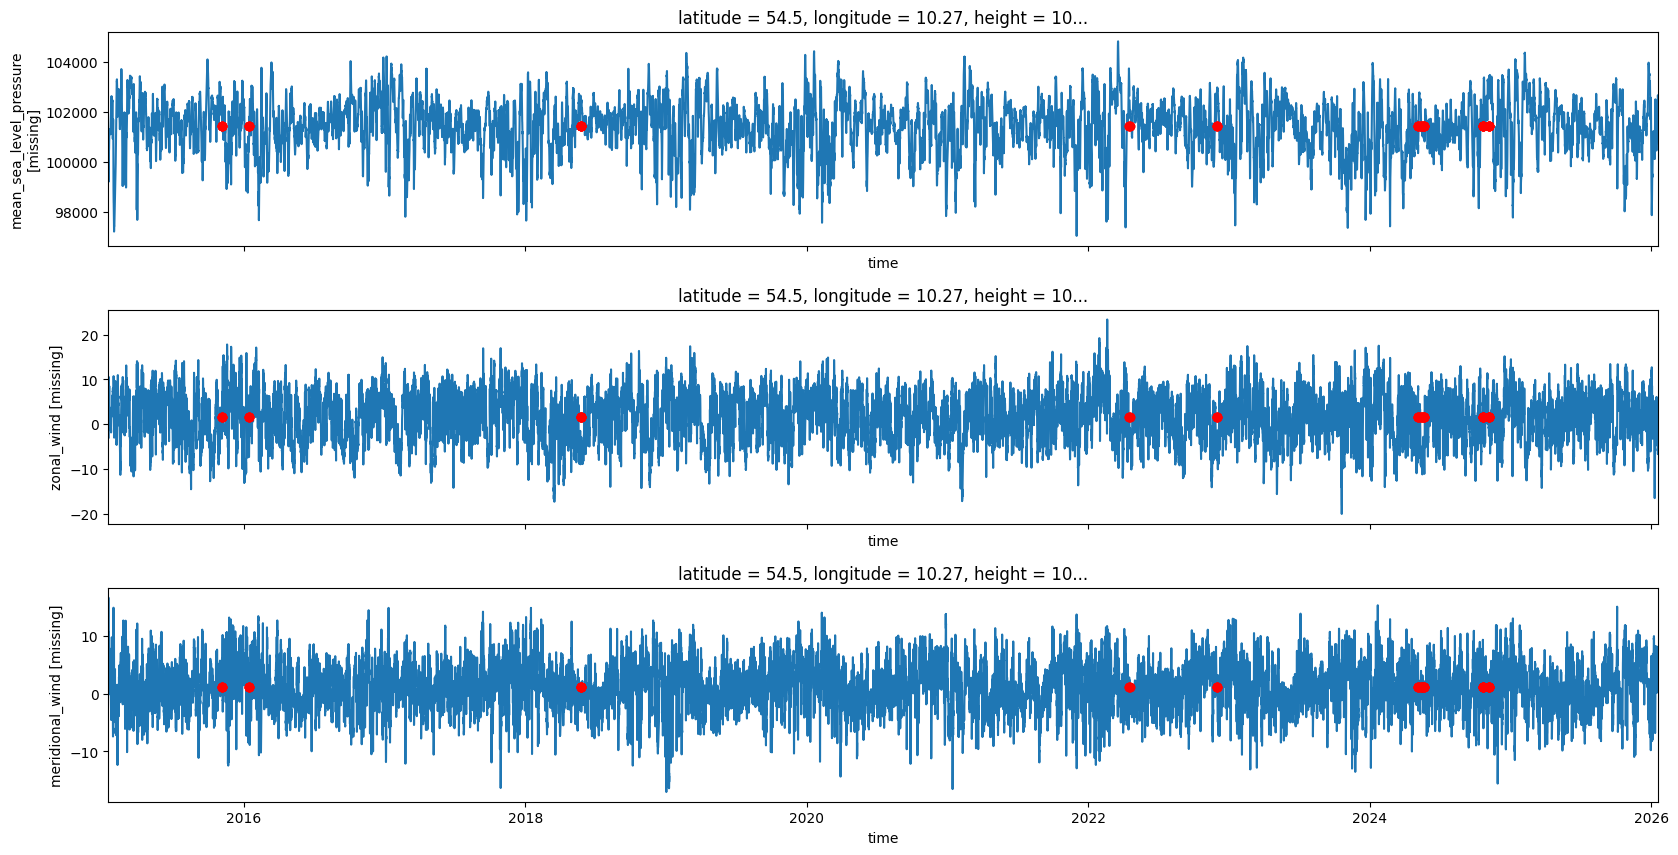

In [81]:
fig, axs = plt.subplots(figsize=(20, 10), nrows=3, sharex=True)

time_for_nan_vals = gfs_data['time'].values[np.isnan(gfs_data['zonal_wind'])]
time_for_nan_vals = time_for_nan_vals[(time_for_nan_vals >= lower_limit) & (time_for_nan_vals <= upper_limit)]

for idx, data_var in enumerate(gfs_data.data_vars):
    gfs_data[data_var].plot(ax=axs[idx])
    # Highlight NaN values with red dots.
    axs[idx].plot(time_for_nan_vals, np.nanmean(gfs_data[data_var]).repeat(time_for_nan_vals.size), 'ro')
    axs[idx].set_xlim((lower_limit, upper_limit))

plt.subplots_adjust(hspace=0.3)

## **3.** Store complete dataset

In [67]:
# Create the data directory if necessary.
data_path = './data'
os.makedirs(data_path, exist_ok=True)

In [ ]:
file_name = 'GFS_full_dataset.nc'
gfs_data.to_netcdf(os.path.join(data_path, file_name))